# 02 — Prompt comparison
### Comparer baseline_prompt.txt et improved_prompt.txt sur les mêmes cas.
Mini batch check (sample d'image) pour vérifier la pertinence du model

### Import des libraries

In [8]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from src.inference import vlm_predict_placeholder
from src.guardrails import apply_safety_guardrails

### Improved prompt with MedGemma

In [ ]:
sample = Path('../data/sample_images/CXR_SYN_002_suspected_opacity.png')
apply_safety_guardrails(vlm_predict_placeholder(sample, mode='improved'))

### Baseline with MedGemma

In [ ]:
sample = Path('../data/sample_images/CXR_SYN_002_suspected_opacity.png')
apply_safety_guardrails(vlm_predict_placeholder(sample, mode='baseline'))

Le prompt "baseline" semble plus proche dela réalité que le "improved" avec le test sur l'image qui a une opacité suspectée.

### Check le nombre d'images disponibles et le temps pour tester le modèle

In [6]:
data_root = Path('../data')
folder = 'brutes'
total = len(list((data_root / folder).glob('*.jpg')))
print(f"Total images : {total}")
print(f"Temps estimé VLM : ~{total * 40 // 60} minutes")

Total images : 932
Temps estimé VLM : ~621 minutes


### Resultat du mini batch
Run avec le fichier : scripts\ `run_batch.py` pour éviter les problèmes de gpu

In [11]:
# print batch_results.csv saved under results directory as csvfile
df_final = pd.read_csv('../results/batch_results.csv')
display(df_final)

,case_id,file,path,folder,ground_truth,toy_class,toy_confidence,vlm_baseline_class,vlm_baseline_confidence,vlm_improved_class,vlm_improved_confidence
0,1,NORMAL-LUNG_00115_normal_142.jpg,data\normal_lung_probe\NORMAL-LUNG_00115_norma...,normal_lung_probe,normal,normal,0.743,normal,0.95,normal,0.8
1,2,NORMAL-LUNG_00026_normal_036.jpg,data\normal_lung_probe\NORMAL-LUNG_00026_norma...,normal_lung_probe,normal,normal,0.730,normal,0.95,normal,0.8
2,3,NORMAL-LUNG_00282_normal_320.jpg,data\normal_lung_probe\NORMAL-LUNG_00282_norma...,normal_lung_probe,normal,normal,0.752,normal,0.95,normal,0.8
3,4,NORMAL-LUNG_00251_normal_285.jpg,data\normal_lung_probe\NORMAL-LUNG_00251_norma...,normal_lung_probe,normal,normal,0.728,normal,0.95,normal,0.8
4,5,NORMAL-LUNG_00229_normal_262.jpg,data\normal_lung_probe\NORMAL-LUNG_00229_norma...,normal_lung_probe,normal,normal,0.739,normal,0.95,normal,0.8
5,6,ABNORMAL-LUNG_00143_suspected_opacity_152.jpg,data\lung_images\ABNORMAL-LUNG_00143_suspected...,lung_images,suspected_opacity,suspected_opacity,0.704,normal,0.95,normal,0.8
6,7,NORMAL-LUNG_00755_normal_374.jpg,data\lung_images\NORMAL-LUNG_00755_normal_374.jpg,lung_images,normal,normal,0.731,normal,0.80,normal,0.8
7,8,ABNORMAL-LUNG_00105_suspected_opacity_112.jpg,data\lung_images\ABNORMAL-LUNG_00105_suspected...,lung_images,suspected_opacity,suspected_opacity,0.717,suspected_opacity,0.30,normal,0.8
8,9,NORMAL-LUNG_00693_normal_308.jpg,data\lung_images\NORMAL-LUNG_00693_normal_308.jpg,lung_images,normal,normal,0.747,normal,0.95,normal,0.8
9,10,NORMAL-LUNG_00759_normal_378.jpg,data\lung_images\NORMAL-LUNG_00759_normal_378.jpg,lung_images,normal,normal,0.714,normal,0.95,normal,0.8


### Calculs des métriques pour la comparaison


=== VLM Baseline ===
Total             : 15
Taux uncertain    : 6.7%
Accuracy          : 60.0%
Macro F1          : 0.337
Sensibilité       : 14.3%
Spécificité       : 61.5%


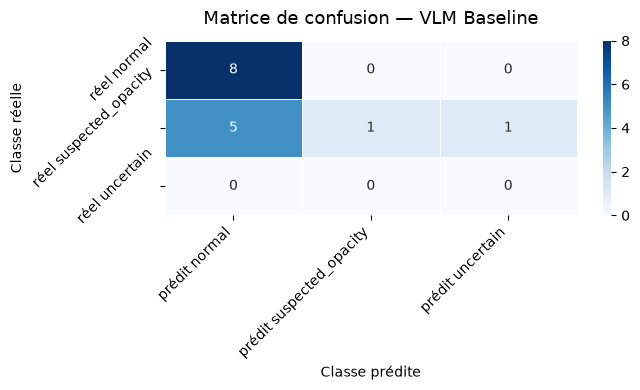


=== VLM Improved ===
Total             : 15
Taux uncertain    : 0.0%
Accuracy          : 53.3%
Macro F1          : 0.232
Sensibilité       : 0.0%
Spécificité       : 53.3%


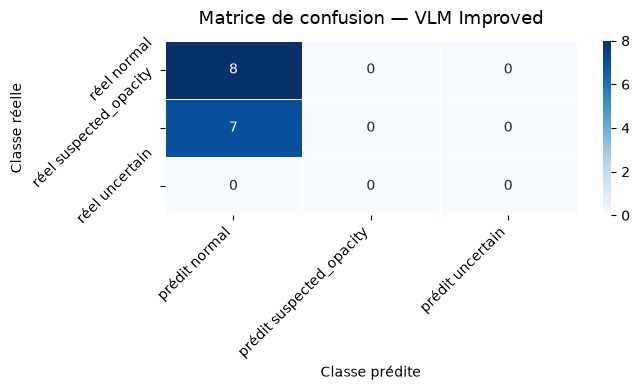

In [9]:
from src.metrics import summarize_metrics, confusion_matrix_numpy

df_final = pd.read_csv('../results/batch_results.csv')

CLASSES = ['normal', 'suspected_opacity', 'uncertain']
modes = {
    'VLM Baseline': 'vlm_baseline_class',
    'VLM Improved': 'vlm_improved_class',
}

for label, col in modes.items():
    print(f"\n=== {label} ===")
    valid = df_final[df_final[col].notna() & (df_final[col] != 'error')].copy()

    # Métriques globales (uncertain inclus)
    rows = [{"label": t, "predicted_class": p, "warning": True}
            for t, p in zip(valid['ground_truth'], valid[col])]
    m = summarize_metrics(rows)
    print(f"Total             : {m['n']}")
    print(f"Taux uncertain    : {m['uncertain_rate']:.1%}")
    print(f"Accuracy          : {m['accuracy']:.1%}")
    print(f"Macro F1          : {m['macro_f1']:.3f}")
    print(f"Sensibilité       : {m['sensitivity']:.1%}")
    print(f"Spécificité       : {m['specificity']:.1%}")

    # Matrice de confusion
    cm = confusion_matrix_numpy(valid['ground_truth'], valid[col], CLASSES)
    cm_df = pd.DataFrame(cm,
        index=[f'réel {c}' for c in CLASSES],
        columns=[f'prédit {c}' for c in CLASSES])

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title(f'Matrice de confusion — {label}', fontsize=13, pad=12)
    ax.set_ylabel('Classe réelle')
    ax.set_xlabel('Classe prédite')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()